# Hospital Operations & Bed Utilisation — Analysis Notebook

**Project 06 · Healthcare operations analytics**

This notebook runs the ten SQL queries in `sql/sqlite/` against the synthetic 15-hospital network in
`data/hospital_operations.db` and turns each result set into a chart an operations director would use:

| # | Query | Operational question |
|---|-------|----------------------|
| 01 | Daily bed occupancy by department | How full is every ward, every day? |
| 02 | Monthly occupancy by department | Which specialties run hottest, and when? |
| 03 | Length of stay: average, median, P90 | Where do stays run long versus peers? |
| 04 | Stranded patients & weekend discharges | How much capacity is locked in long stays? |
| 05 | ED wait-time weekly trends | Are ED waits improving, and where? |
| 06 | ED waits by hour and triage | When in the day does the ED fall behind? |
| 07 | 30-day readmissions | Who comes back within a month? |
| 08 | Readmission risk drivers | Which patients should transitional care target? |
| 09 | Capacity bottlenecks | Which wards are *persistently* full, and does it block the ED? |
| 10 | Staffing pressure & scorecard | Are wards staffed for the patients in the beds? |

Charts are written to `charts/` and reused in the slide deck. All data is synthetic.

In [1]:
import sqlite3
from pathlib import Path

import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import matplotlib.ticker as mtick
import numpy as np
import pandas as pd
from matplotlib.colors import LinearSegmentedColormap

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
DB = ROOT / "data" / "hospital_operations.db"
SQL = ROOT / "sql" / "sqlite"
CHARTS = ROOT / "charts"
CHARTS.mkdir(exist_ok=True)
con = sqlite3.connect(DB)

def run_query(stem: str) -> pd.DataFrame:
    """Execute one of the project's SQL files and return the result set."""
    return pd.read_sql_query((SQL / f"{stem}.sql").read_text(), con)

pd.set_option("display.max_columns", 30)
pd.set_option("display.width", 200)

### Visual theme
One palette is shared by the notebook and the slide deck: **clinical teal** carries the story, grey is context,
amber marks the 85% planning line and red the 95% "no slack" line. Hospital types use a three-colour categorical set
(teal / burnt orange / violet) that passes colour-vision-deficiency checks.

In [2]:
TEAL, DEEP, INK, MUTED, GRID, CONTEXT = "#00949C", "#0B3C44", "#1B2A32", "#5B6B73", "#E3E8EA", "#A7B1B6"
ORANGE, VIOLET, AMBER, RED = "#C9572A", "#5B4BA8", "#D99A00", "#C0392B"
TYPE_COLORS = {"Teaching": TEAL, "Regional General": ORANGE, "Community": VIOLET}
SEQ = LinearSegmentedColormap.from_list("teal_seq", ["#EEF6F7", "#8CCBCF", TEAL, DEEP])

plt.rcParams.update({
    "figure.dpi": 110, "savefig.dpi": 200, "figure.facecolor": "white",
    "font.family": "DejaVu Sans", "font.size": 10, "text.color": INK,
    "axes.edgecolor": GRID, "axes.labelcolor": MUTED, "axes.titlesize": 12.5, "axes.titlepad": 22,
    "axes.titleweight": "bold", "axes.titlelocation": "left", "axes.titlecolor": INK,
    "axes.spines.top": False, "axes.spines.right": False, "axes.grid": True,
    "grid.color": GRID, "grid.linewidth": 0.8, "xtick.color": MUTED, "ytick.color": MUTED,
    "legend.frameon": False,
})

def subtitle(ax, text):
    ax.text(0, 1.02, text, transform=ax.transAxes, color=MUTED, fontsize=9.5, va="bottom")

def save(fig, name):
    fig.savefig(CHARTS / f"{name}.png", bbox_inches="tight")

## 0 · The dataset

In [3]:
tables = ["hospitals", "departments", "bed_capacity", "patients", "admissions", "er_visits", "staffing_shifts"]
pd.DataFrame({"rows": [con.execute(f"SELECT COUNT(*) FROM {t}").fetchone()[0] for t in tables]}, index=tables)

,rows
hospitals,15
departments,9
bed_capacity,147
patients,159826
admissions,95393
er_visits,196224
staffing_shifts,89790


In [4]:
pd.read_sql_query("""
    SELECT h.hospital_code, h.hospital_name, h.hospital_type, h.region,
           SUM(CASE WHEN d.is_inpatient = 1 THEN b.staffed_beds END) AS inpatient_beds,
           SUM(CASE WHEN d.is_inpatient = 0 THEN b.staffed_beds END) AS ed_bays
    FROM hospitals h
    JOIN bed_capacity b ON b.hospital_id = h.hospital_id AND b.effective_to IS NULL
    JOIN departments d ON d.department_id = b.department_id
    GROUP BY h.hospital_id ORDER BY inpatient_beds DESC
""", con)

,hospital_code,hospital_name,hospital_type,region,inpatient_beds,ed_bays
0,SAU,St Aldric University Hospital,Teaching,North,151,20
1,QET,Queen Eleanor Teaching Hospital,Teaching,Central,148,20
2,PNT,Pennant University Hospital,Teaching,West,138,19
3,HBV,Harbourview Medical Centre,Regional General,East,91,12
4,SDN,Southdown General Hospital,Regional General,South,87,11
5,WBG,Westbrook General Hospital,Regional General,West,85,12
6,TMS,Thameside General Hospital,Regional General,South,79,11
7,EFG,Eastfield General Hospital,Regional General,East,79,11
8,KMR,Kingsmead Regional Hospital,Regional General,Central,79,11
9,RVG,Riverside General Hospital,Regional General,North,79,11


## 1 · Daily bed occupancy (query 01)
Midnight census against *staffed* beds, built from admission/discharge movements with a running `SUM() OVER`.

In [5]:
occ = run_query("01_daily_bed_occupancy_by_department")
occ["census_date"] = pd.to_datetime(occ["census_date"])
occ.head()

,hospital_code,department_code,census_date,staffed_beds,occupied_beds,occupancy_rate,occupancy_7d_avg,occupancy_band
0,ASH,ICU,2025-01-01,4,1,0.25,0.2500,Normal (<85%)
1,ASH,ICU,2025-01-02,4,1,0.25,0.2500,Normal (<85%)
2,ASH,ICU,2025-01-03,4,2,0.50,0.3333,Normal (<85%)
3,ASH,ICU,2025-01-04,4,3,0.75,0.4375,Normal (<85%)
4,ASH,ICU,2025-01-05,4,3,0.75,0.5000,Normal (<85%)


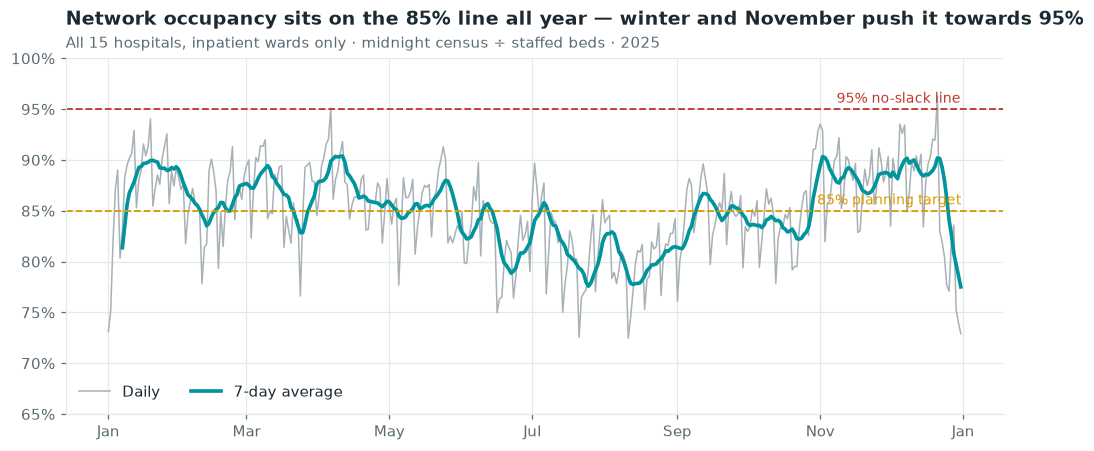

Mean 85.0% · peak 96.3% on 21 Dec · ward-days at ≥95%: 34% · over 100%: 22%


In [6]:
net = occ.groupby("census_date")[["occupied_beds", "staffed_beds"]].sum()
net["occupancy"] = net.occupied_beds / net.staffed_beds
net["occ_7d"] = net.occupancy.rolling(7).mean()

fig, ax = plt.subplots(figsize=(11, 4.2))
ax.plot(net.index, net.occupancy, color=CONTEXT, lw=1, label="Daily")
ax.plot(net.index, net.occ_7d, color=TEAL, lw=2.4, label="7-day average")
ax.axhline(0.85, color=AMBER, lw=1.2, ls="--")
ax.axhline(0.95, color=RED, lw=1.2, ls="--")
ax.text(net.index[-1], 0.853, " 85% planning target", color=AMBER, fontsize=9, va="bottom", ha="right")
ax.text(net.index[-1], 0.953, " 95% no-slack line", color=RED, fontsize=9, va="bottom", ha="right")
ax.yaxis.set_major_formatter(mtick.PercentFormatter(1, decimals=0))
ax.xaxis.set_major_formatter(mdates.DateFormatter("%b"))
ax.set_ylim(0.65, 1.0)
ax.set_title("Network occupancy sits on the 85% line all year — winter and November push it towards 95%")
subtitle(ax, "All 15 hospitals, inpatient wards only · midnight census ÷ staffed beds · 2025")
ax.legend(loc="lower left", ncol=2)
save(fig, "01_network_daily_occupancy")
plt.show()
print(f"Mean {net.occupancy.mean():.1%} · peak {net.occupancy.max():.1%} on {net.occupancy.idxmax():%d %b} · "
      f"ward-days at ≥95%: {(occ.occupancy_rate >= 0.95).mean():.0%} · over 100%: {(occ.occupancy_rate > 1).mean():.0%}")

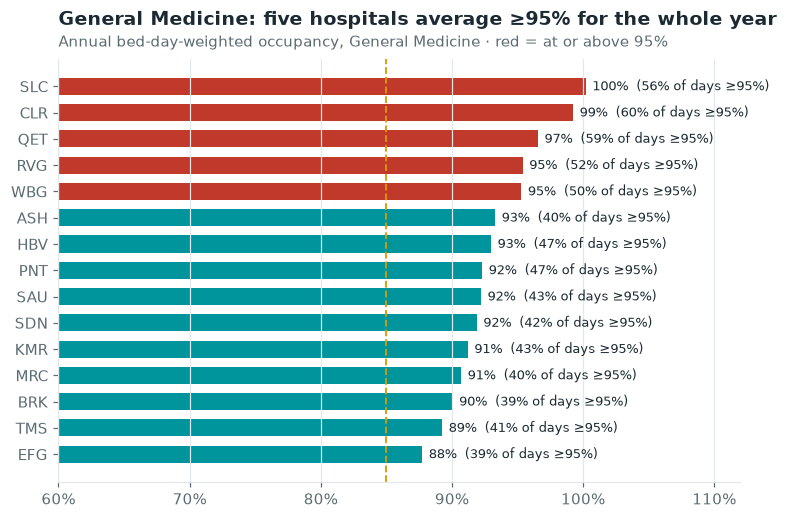

In [7]:
# The average hides the spread: occupancy by hospital for General Medicine, the largest specialty
med = occ[occ.department_code == "MED"].groupby("hospital_code").apply(
    lambda g: pd.Series({"occupancy": g.occupied_beds.sum() / g.staffed_beds.sum(),
                         "days_ge_95": (g.occupancy_rate >= 0.95).mean()})).sort_values("occupancy")
fig, ax = plt.subplots(figsize=(8, 5))
colors = [RED if v >= 0.95 else TEAL for v in med.occupancy]
ax.barh(med.index, med.occupancy, color=colors, height=0.65)
ax.axvline(0.85, color=AMBER, ls="--", lw=1.2)
for y, (v, d) in enumerate(zip(med.occupancy, med.days_ge_95)):
    ax.text(v + 0.005, y, f"{v:.0%}  ({d:.0%} of days ≥95%)", va="center", fontsize=8.5, color=INK)
ax.xaxis.set_major_formatter(mtick.PercentFormatter(1, decimals=0))
ax.set_xlim(0.6, 1.12); ax.grid(axis="y", visible=False)
ax.set_title("General Medicine: five hospitals average ≥95% for the whole year")
subtitle(ax, "Annual bed-day-weighted occupancy, General Medicine · red = at or above 95%")
save(fig, "01b_medicine_occupancy_by_hospital")
plt.show()

## 2 · Monthly occupancy by department (query 02)
Bed-day weighted, with `RANK()` within month and `LAG()` for the month-on-month change.

In [8]:
monthly = run_query("02_monthly_occupancy_by_department")
monthly.sort_values(["share_ward_days_ge_95"], ascending=False).head(8)

,month,department_code,department_name,staffed_bed_days,occupied_bed_days,occupancy_rate,gap_to_target,peak_ward_occupancy,share_ward_days_ge_85,share_ward_days_ge_95,rank_in_month,mom_change_pp
0,2025-01,ICU,Intensive Care,2666,2867,1.0754,0.2754,2.8000,0.6323,0.6194,1,NaN
24,2025-04,MED,General Medicine,11070,11048,0.9980,0.0980,1.6923,0.7400,0.6067,1,9.57
88,2025-12,MED,General Medicine,12276,12027,0.9797,0.0797,2.0769,0.6989,0.5699,1,0.88
64,2025-09,MED,General Medicine,11070,10396,0.9391,0.0391,1.5385,0.6911,0.5289,1,6.74
80,2025-11,MED,General Medicine,11070,10748,0.9709,0.0709,1.5000,0.7200,0.5178,1,2.34
32,2025-05,MED,General Medicine,11439,10840,0.9476,0.0476,1.6154,0.6946,0.5075,1,-5.04
25,2025-04,ONC,Oncology,2550,2449,0.9604,0.1104,2.3333,0.5788,0.5061,2,11.67
17,2025-03,ICU,Intensive Care,2666,2396,0.8987,0.0987,2.5000,0.5441,0.4925,2,-3.61


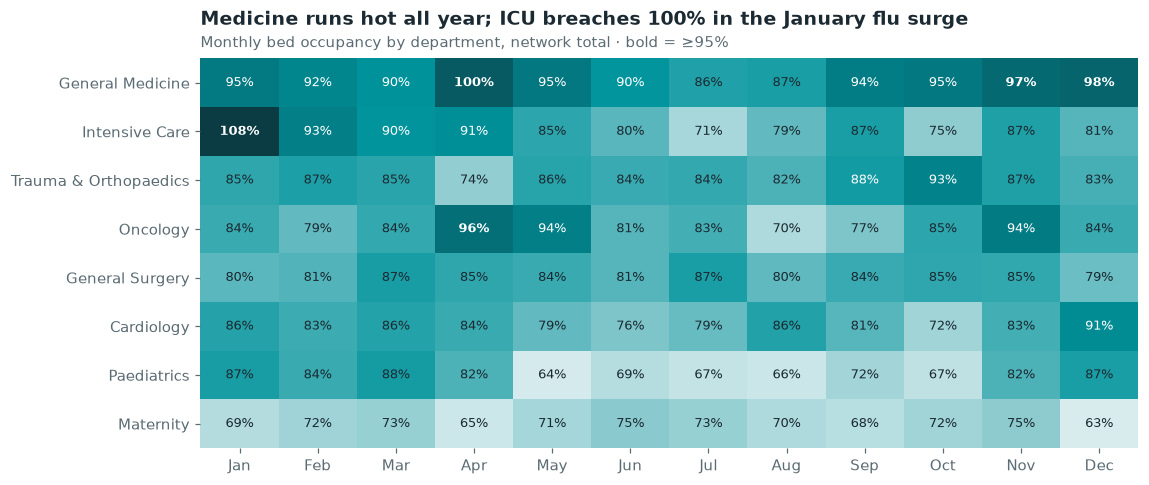

In [9]:
heat = monthly.pivot(index="department_name", columns="month", values="occupancy_rate")
heat = heat.loc[heat.mean(axis=1).sort_values(ascending=False).index]
heat.columns = pd.to_datetime(heat.columns).strftime("%b")

fig, ax = plt.subplots(figsize=(11, 4.6))
im = ax.imshow(heat.values, cmap=SEQ, vmin=0.6, vmax=1.05, aspect="auto")
ax.set_xticks(range(heat.shape[1]), heat.columns)
ax.set_yticks(range(heat.shape[0]), heat.index)
ax.grid(False)
for s in ax.spines.values(): s.set_visible(False)
for i in range(heat.shape[0]):
    for j in range(heat.shape[1]):
        v = heat.values[i, j]
        ax.text(j, i, f"{v:.0%}", ha="center", va="center", fontsize=8.5,
                color="white" if v > 0.88 else INK, fontweight="bold" if v >= 0.95 else "normal")
ax.set_title("Medicine runs hot all year; ICU breaches 100% in the January flu surge")
subtitle(ax, "Monthly bed occupancy by department, network total · bold = ≥95%")
save(fig, "02_department_month_heatmap")
plt.show()

In [10]:
# Month-on-month swings (LAG): the April jump in Medicine follows escalation beds closing on 31 March
monthly[monthly.department_code == "MED"][["month", "occupancy_rate", "mom_change_pp", "share_ward_days_ge_95", "rank_in_month"]]

,month,occupancy_rate,mom_change_pp,share_ward_days_ge_95,rank_in_month
1,2025-01,0.9462,NaN,0.4581,2
9,2025-02,0.9223,-2.39,0.4333,2
16,2025-03,0.9023,-2.01,0.4215,1
24,2025-04,0.9980,9.57,0.6067,1
32,2025-05,0.9476,-5.04,0.5075,1
40,2025-06,0.8955,-5.22,0.3933,1
49,2025-07,0.8639,-3.16,0.2946,2
56,2025-08,0.8717,0.78,0.3613,1
64,2025-09,0.9391,6.74,0.5289,1
72,2025-10,0.9475,0.84,0.4753,1


## 3 · Length of stay — average, median and P90 (query 03)
Percentiles via `ROW_NUMBER()/COUNT()` so the same SQL runs on SQLite and PostgreSQL. Excess bed-days compare each
hospital's ALOS with the network benchmark for the same specialty.

In [11]:
los = run_query("03_length_of_stay_avg_p90")
net_los = los[los.hospital == "NETWORK"].set_index("department_code").sort_values("alos_days")
net_los[["discharges", "alos_days", "median_los_days", "p90_los_days", "p90_to_mean_ratio"]]

,discharges,alos_days,median_los_days,p90_los_days,p90_to_mean_ratio
department_code,,,,,
PAED,11129,2.07,1.63,4.02,1.94
MAT,10568,2.77,2.29,5.16,1.87
SURG,19181,3.63,2.52,7.33,2.02
ICU,6944,4.00,2.95,8.02,2.01
CARD,7568,4.06,2.97,8.29,2.04
ORTH,7540,5.31,3.72,11.29,2.13
MED,18665,6.90,4.90,14.09,2.04
ONC,3543,7.41,5.25,15.26,2.06


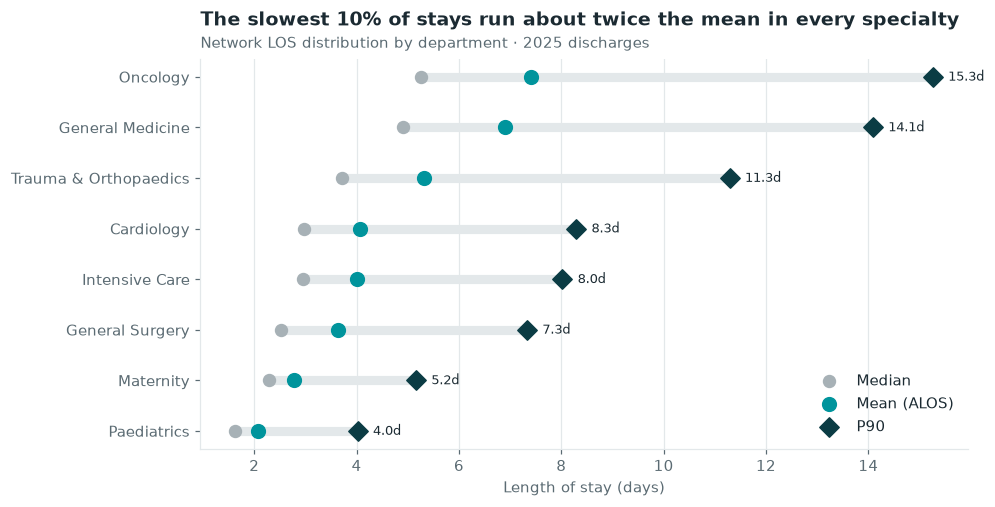

In [12]:
dept_names = pd.read_sql_query("SELECT department_code, department_name FROM departments", con).set_index("department_code").department_name
fig, ax = plt.subplots(figsize=(9, 4.6))
y = np.arange(len(net_los))
ax.hlines(y, net_los.median_los_days, net_los.p90_los_days, color=GRID, lw=6, zorder=1)
ax.scatter(net_los.median_los_days, y, color=CONTEXT, s=60, zorder=2, label="Median")
ax.scatter(net_los.alos_days, y, color=TEAL, s=80, zorder=3, label="Mean (ALOS)")
ax.scatter(net_los.p90_los_days, y, color=DEEP, s=80, marker="D", zorder=3, label="P90")
for yi, p in zip(y, net_los.p90_los_days):
    ax.text(p + 0.3, yi, f"{p:.1f}d", va="center", fontsize=8.5, color=INK)
ax.set_yticks(y, dept_names.loc[net_los.index])
ax.set_xlabel("Length of stay (days)")
ax.grid(axis="y", visible=False)
ax.legend(loc="lower right")
ax.set_title("The slowest 10% of stays run about twice the mean in every specialty")
subtitle(ax, "Network LOS distribution by department · 2025 discharges")
save(fig, "03_los_mean_median_p90")
plt.show()

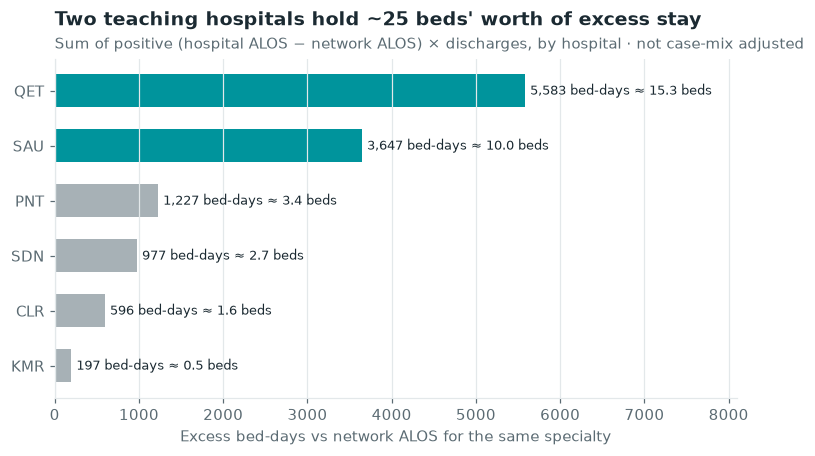

In [13]:
excess = (los[los.hospital != "NETWORK"].assign(excess=lambda d: d.excess_bed_days.clip(lower=0))
          .groupby("hospital").excess.sum().sort_values())
excess = excess[excess > 50]
fig, ax = plt.subplots(figsize=(8, 4))
ax.barh(excess.index, excess.values, color=[TEAL if v > 3000 else CONTEXT for v in excess.values], height=0.6)
for yi, v in enumerate(excess.values):
    ax.text(v + 60, yi, f"{v:,.0f} bed-days ≈ {v / 365:.1f} beds", va="center", fontsize=8.5)
ax.set_xlim(0, excess.max() * 1.45); ax.grid(axis="y", visible=False)
ax.set_xlabel("Excess bed-days vs network ALOS for the same specialty")
ax.set_title("Two teaching hospitals hold ~25 beds' worth of excess stay")
subtitle(ax, "Sum of positive (hospital ALOS − network ALOS) × discharges, by hospital · not case-mix adjusted")
save(fig, "03b_excess_bed_days")
plt.show()

## 4 · Stranded patients and the weekend discharge gap (query 04)

In [14]:
stranded = run_query("04_stranded_patients_and_weekend_discharges")
stranded

,hospital_code,hospital_type,discharges,stranded_share,super_stranded_share,stranded_bed_day_share,super_stranded_bed_day_share,weekend_discharge_ratio,monday_surge_ratio,stranded_pct_rank,weekend_gap_pct_rank
0,QET,Teaching,9414,0.2024,0.0218,0.5301,0.1349,0.635,1.507,1.000,0.214
1,SAU,Teaching,10088,0.1838,0.0195,0.5044,0.1243,0.630,1.562,0.929,0.429
2,SDN,Regional General,5721,0.1689,0.0170,0.4805,0.1088,0.625,1.470,0.857,0.643
3,PNT,Teaching,9499,0.1672,0.0175,0.4792,0.1152,0.650,1.472,0.786,0.071
4,CLR,Regional General,5265,0.1677,0.0152,0.4703,0.0996,0.654,1.511,0.714,0.000
5,KMR,Regional General,5455,0.1635,0.0141,0.4688,0.0970,0.612,1.524,0.643,0.786
6,ASH,Community,2237,0.1591,0.0130,0.4572,0.0896,0.609,1.533,0.571,0.857
7,HBV,Regional General,6640,0.1541,0.0127,0.4548,0.0911,0.635,1.521,0.500,0.286
8,SLC,Community,2255,0.1557,0.0111,0.4511,0.0825,0.578,1.554,0.429,1.000
9,BRK,Community,2234,0.1576,0.0103,0.4425,0.0629,0.619,1.348,0.357,0.714


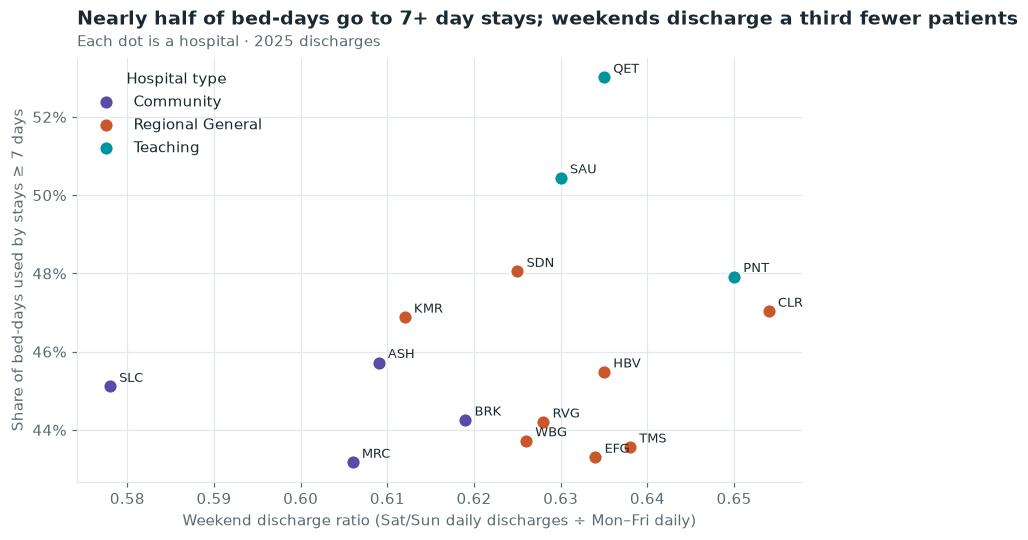

Network: weekend discharge ratio 0.63, Monday surge 1.49x Tue–Fri


In [15]:
fig, ax = plt.subplots(figsize=(8.5, 5))
for t, g in stranded.groupby("hospital_type"):
    ax.scatter(g.weekend_discharge_ratio, g.stranded_bed_day_share, s=90, color=TYPE_COLORS[t],
               label=t, edgecolor="white", linewidth=1.5, zorder=3)
for _, r in stranded.iterrows():
    ax.annotate(r.hospital_code, (r.weekend_discharge_ratio, r.stranded_bed_day_share),
                xytext=(6, 3), textcoords="offset points", fontsize=8.5, color=INK)
ax.yaxis.set_major_formatter(mtick.PercentFormatter(1, decimals=0))
ax.set_xlabel("Weekend discharge ratio (Sat/Sun daily discharges ÷ Mon–Fri daily)")
ax.set_ylabel("Share of bed-days used by stays ≥ 7 days")
ax.legend(title="Hospital type", loc="upper left")
ax.set_title("Nearly half of bed-days go to 7+ day stays; weekends discharge a third fewer patients")
subtitle(ax, "Each dot is a hospital · 2025 discharges")
save(fig, "04_stranded_vs_weekend")
plt.show()
print(f"Network: weekend discharge ratio {stranded.weekend_discharge_ratio.mean():.2f}, "
      f"Monday surge {stranded.monday_surge_ratio.mean():.2f}x Tue–Fri")

## 5 · ED wait-time trends (query 05)
Weekly door-to-provider time with a 4-week moving average (`AVG() OVER ROWS 3 PRECEDING`), week-on-week change
(`LAG()`), and change versus the first week (`FIRST_VALUE()`).

In [16]:
ed = run_query("05_er_wait_time_weekly_trends")
ed["week_start"] = pd.to_datetime(ed["week_start"])
ed.head()

,hospital_code,week_start,attendances,avg_door_to_provider_min,p90_door_to_provider_min,avg_wait_4wk_moving_avg,week_on_week_change_min,change_vs_first_week_min,within_4h_rate,within_4h_4wk_moving_avg,lwbs_rate
0,ASH,2025-01-06,93,41.5,79.0,41.5,NaN,0.0,0.8817,0.8817,0.0108
1,ASH,2025-01-13,118,39.4,79.0,40.4,-2.1,-2.1,0.9407,0.9112,0.0000
2,ASH,2025-01-20,80,45.7,104.0,42.2,6.3,4.2,0.7875,0.8700,0.0125
3,ASH,2025-01-27,98,27.9,56.0,38.6,-17.7,-13.5,0.9490,0.8897,0.0000
4,ASH,2025-02-03,61,22.8,49.0,33.9,-5.2,-18.7,0.9180,0.8988,0.0164


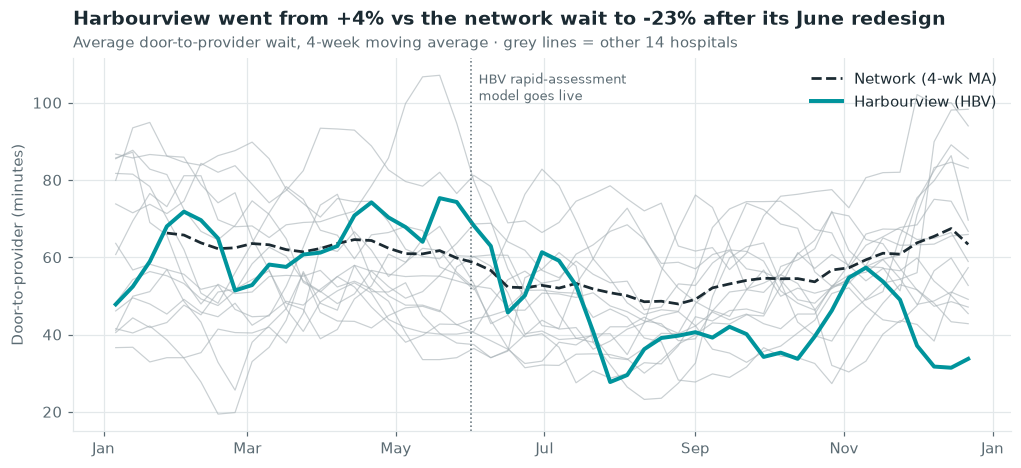

In [17]:
network_week = ed.groupby("week_start").apply(
    lambda g: np.average(g.avg_door_to_provider_min, weights=g.attendances)).rolling(4).mean()
fig, ax = plt.subplots(figsize=(11, 4.4))
for code_, g in ed.groupby("hospital_code"):
    if code_ != "HBV":
        ax.plot(g.week_start, g.avg_wait_4wk_moving_avg, color=CONTEXT, lw=0.8, alpha=0.6)
hbv = ed[ed.hospital_code == "HBV"]
hbv_ratio = hbv.set_index("week_start").avg_door_to_provider_min / ed.groupby("week_start").apply(
    lambda g: np.average(g.avg_door_to_provider_min, weights=g.attendances))
pre, post = hbv_ratio[hbv_ratio.index < "2025-06-02"].mean(), hbv_ratio[hbv_ratio.index >= "2025-06-02"].mean()
ax.plot(network_week.index, network_week.values, color=INK, lw=1.8, ls="--", label="Network (4-wk MA)")
ax.plot(hbv.week_start, hbv.avg_wait_4wk_moving_avg, color=TEAL, lw=2.6, label="Harbourview (HBV)")
ax.axvline(pd.Timestamp("2025-06-01"), color=MUTED, lw=1, ls=":")
ax.text(pd.Timestamp("2025-06-04"), ax.get_ylim()[1] * 0.97, "HBV rapid-assessment\nmodel goes live",
        fontsize=8.5, color=MUTED, va="top")
ax.xaxis.set_major_formatter(mdates.DateFormatter("%b"))
ax.set_ylabel("Door-to-provider (minutes)")
ax.legend(loc="upper right")
ax.set_title(f"Harbourview went from {pre - 1:+.0%} vs the network wait to {post - 1:+.0%} after its June redesign")
subtitle(ax, "Average door-to-provider wait, 4-week moving average · grey lines = other 14 hospitals")
save(fig, "05_ed_wait_trend")
plt.show()

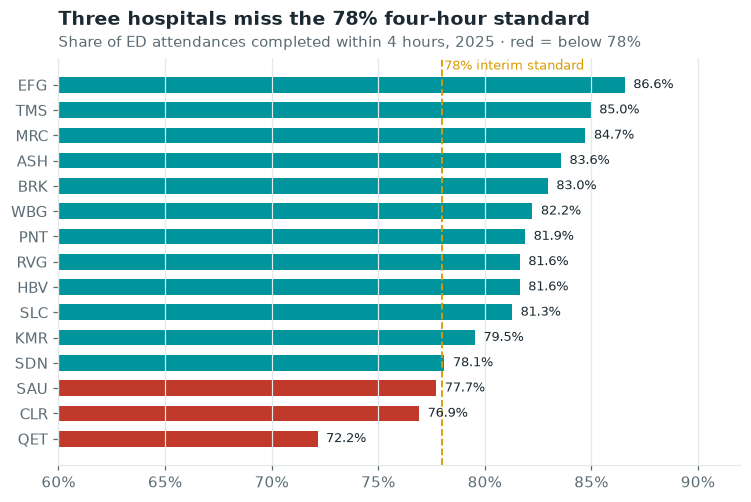

In [18]:
ed_h = ed.assign(w=lambda d: d.within_4h_rate * d.attendances).groupby("hospital_code").agg(
    att=("attendances", "sum"), w=("w", "sum"))
ed_h["within_4h"] = ed_h.w / ed_h.att
ed_h = ed_h.sort_values("within_4h")
fig, ax = plt.subplots(figsize=(8, 4.8))
ax.barh(ed_h.index, ed_h.within_4h, color=[RED if v < 0.78 else TEAL for v in ed_h.within_4h], height=0.62)
ax.axvline(0.78, color=AMBER, ls="--", lw=1.2)
ax.text(0.781, len(ed_h) - 0.4, "78% interim standard", color=AMBER, fontsize=8.5)
for yi, v in enumerate(ed_h.within_4h):
    ax.text(v + 0.004, yi, f"{v:.1%}", va="center", fontsize=8.5)
ax.set_xlim(0.6, 0.92); ax.grid(axis="y", visible=False)
ax.xaxis.set_major_formatter(mtick.PercentFormatter(1, decimals=0))
n_miss = int((ed_h.within_4h < 0.78).sum())
ax.set_title(f"{['No', 'One', 'Two', 'Three', 'Four', 'Five'][n_miss] if n_miss < 6 else n_miss} hospitals miss the 78% four-hour standard")
subtitle(ax, "Share of ED attendances completed within 4 hours, 2025 · red = below 78%")
save(fig, "05b_ed_4h_by_hospital")
plt.show()

## 6 · ED waits by arrival hour and triage (query 06)

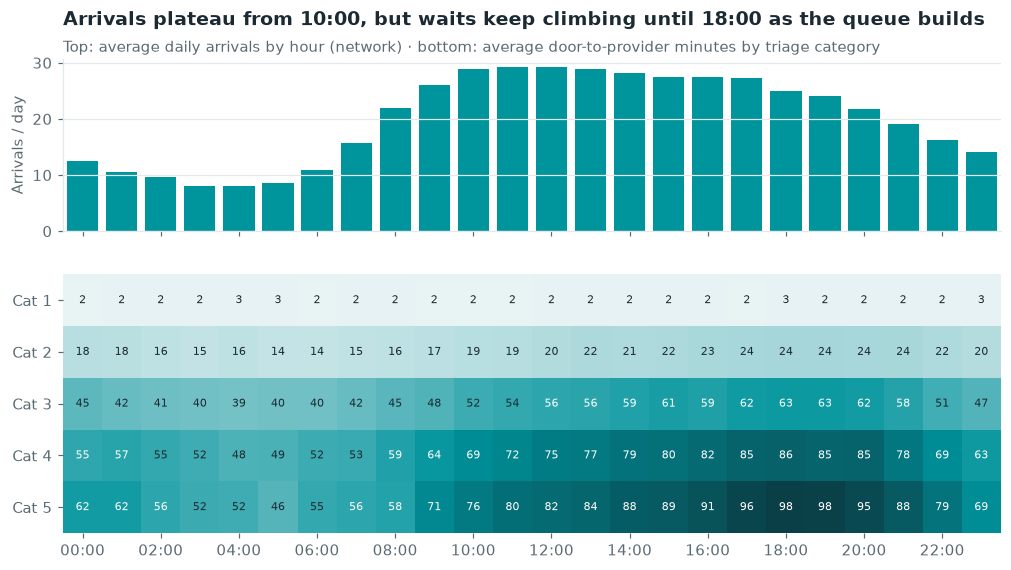

In [19]:
hour = run_query("06_er_wait_by_hour_and_triage")
hm = hour.pivot(index="triage_category", columns="arrival_hour", values="avg_door_to_provider_min")
arrivals = hour.groupby("arrival_hour").avg_daily_arrivals.sum()

fig, (ax0, ax1) = plt.subplots(2, 1, figsize=(11, 5.6), sharex=True, gridspec_kw={"height_ratios": [1, 1.5]})
ax0.bar(arrivals.index, arrivals.values, color=TEAL, width=0.8)
ax0.set_ylabel("Arrivals / day")
ax0.set_title(f"Arrivals plateau from 10:00, but waits keep climbing until {hm.loc[[3, 4, 5]].mean().idxmax():02d}:00 as the queue builds")
subtitle(ax0, "Top: average daily arrivals by hour (network) · bottom: average door-to-provider minutes by triage category")
ax0.grid(axis="x", visible=False)
im = ax1.imshow(hm.values, cmap=SEQ, aspect="auto", vmin=0, vmax=100,
                extent=[-0.5, 23.5, hm.index.max() + 0.5, hm.index.min() - 0.5])
for (i, t) in enumerate(hm.index):
    for h in hm.columns:
        v = hm.loc[t, h]
        ax1.text(h, t, f"{v:.0f}", ha="center", va="center", fontsize=7.5, color="white" if v > 55 else INK)
ax1.set_yticks(hm.index, [f"Cat {t}" for t in hm.index])
ax1.set_xticks(range(0, 24, 2), [f"{h:02d}:00" for h in range(0, 24, 2)])
ax1.grid(False)
for s in ax1.spines.values(): s.set_visible(False)
save(fig, "06_ed_hour_triage")
plt.show()

## 7 · 30-day unplanned readmissions (query 07)
`LEAD()` over each patient's admissions across **all** hospitals — so a readmission elsewhere in the network still counts
against the discharging hospital.

In [20]:
readm = run_query("07_readmissions_within_30_days")
readm

,level,entity,index_stays,readmissions_30d,readmission_rate_30d,readmission_rate_7d,share_readmitted_elsewhere,ratio_to_network,rank_within_level
0,Network,ALL,74129,7834,0.1057,0.0538,0.1246,1.000,NaN
1,Hospital,SLC,1929,288,0.1493,0.0757,0.1667,1.413,1.0
2,Hospital,CLR,4572,591,0.1293,0.0669,0.1303,1.223,2.0
3,Hospital,BRK,1925,239,0.1242,0.0618,0.1088,1.175,3.0
4,Hospital,ASH,1944,229,0.1178,0.0622,0.1354,1.115,4.0
5,Hospital,SDN,5048,586,0.1161,0.0580,0.1229,1.098,5.0
6,Hospital,HBV,5836,654,0.1121,0.0576,0.1101,1.060,6.0
7,Hospital,MRC,2185,243,0.1112,0.0600,0.1605,1.052,7.0
8,Hospital,RVG,5080,562,0.1106,0.0539,0.1032,1.047,8.0
9,Hospital,TMS,5068,550,0.1085,0.0594,0.1091,1.027,9.0


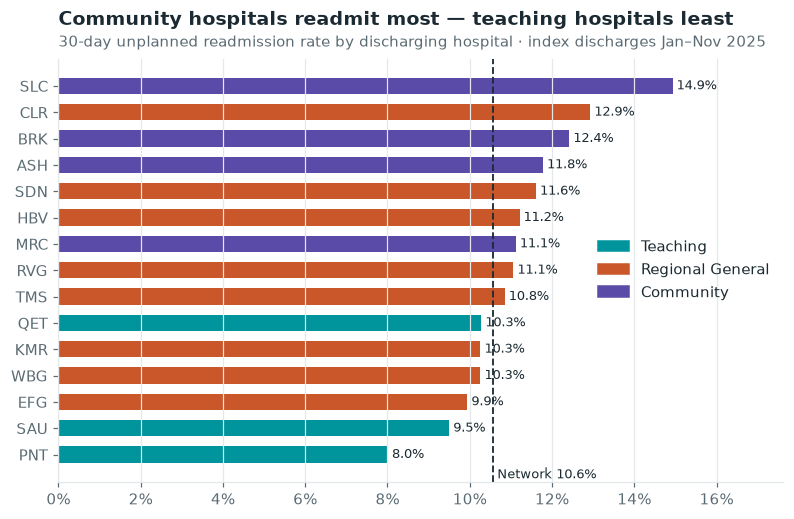

12% of readmissions present at a different hospital — invisible to single-site reporting


In [21]:
hosp_r = readm[readm.level == "Hospital"].sort_values("readmission_rate_30d")
network_rate = readm.loc[readm.level == "Network", "readmission_rate_30d"].item()
types = pd.read_sql_query("SELECT hospital_code, hospital_type FROM hospitals", con).set_index("hospital_code").hospital_type

fig, ax = plt.subplots(figsize=(8.5, 5))
ax.barh(hosp_r.entity, hosp_r.readmission_rate_30d, color=[TYPE_COLORS[types[h]] for h in hosp_r.entity], height=0.62)
ax.axvline(network_rate, color=INK, ls="--", lw=1.2)
ax.text(network_rate + 0.001, -0.9, f"Network {network_rate:.1%}", fontsize=8.5, color=INK)
for yi, (v, e) in enumerate(zip(hosp_r.readmission_rate_30d, hosp_r.share_readmitted_elsewhere)):
    ax.text(v + 0.001, yi, f"{v:.1%}", va="center", fontsize=8.5)
ax.xaxis.set_major_formatter(mtick.PercentFormatter(1, decimals=0))
ax.set_xlim(0, hosp_r.readmission_rate_30d.max() * 1.18); ax.grid(axis="y", visible=False)
handles = [plt.Rectangle((0, 0), 1, 1, color=c) for c in TYPE_COLORS.values()]
ax.legend(handles, TYPE_COLORS.keys(), loc="center right")
ax.set_title("Community hospitals readmit most — teaching hospitals least")
subtitle(ax, "30-day unplanned readmission rate by discharging hospital · index discharges Jan–Nov 2025")
save(fig, "07_readmission_by_hospital")
plt.show()
share_elsewhere = readm.loc[readm.level == "Network", "share_readmitted_elsewhere"].item()
print(f"{share_elsewhere:.0%} of readmissions present at a different hospital — invisible to single-site reporting")

## 8 · What drives readmission? (query 08)

In [22]:
drivers = run_query("08_readmission_risk_drivers")
drivers[drivers.factor != "Diagnosis group"]

,factor,level_value,index_stays,readmissions,readmission_rate_30d,relative_risk,share_of_readmissions,risk_rank_in_factor
0,Admission type,Emergency,56503,6944,0.1229,1.16,0.8864,1
1,Admission type,Elective,17626,890,0.0505,0.48,0.1136,2
2,Age band,85+,6047,922,0.1525,1.44,0.1177,1
3,Age band,75-84,9449,1405,0.1487,1.41,0.1793,2
4,Age band,65-74,11812,1231,0.1042,0.99,0.1571,3
5,Age band,0-17,10020,1025,0.1023,0.97,0.1308,4
6,Age band,45-64,19561,1972,0.1008,0.95,0.2517,5
7,Age band,18-44,17240,1279,0.0742,0.70,0.1633,6
47,Discharge day,Fri-Sun,26264,2962,0.1128,1.07,0.3781,1
48,Discharge day,Mon-Thu,47865,4872,0.1018,0.96,0.6219,2


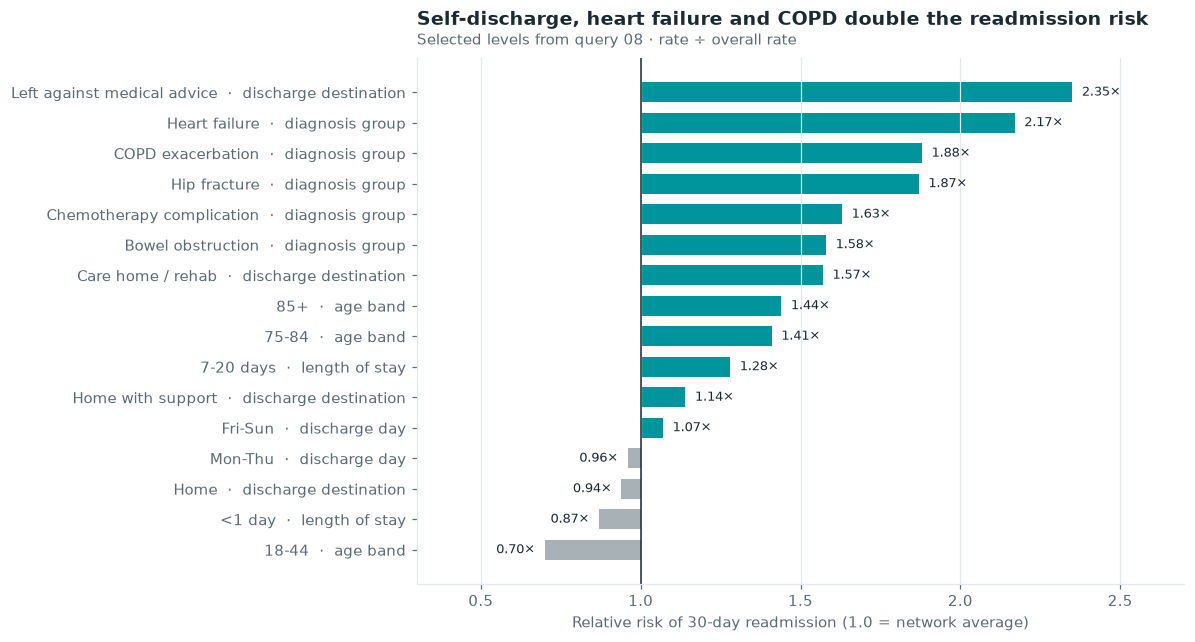

In [23]:
pick = pd.concat([
    drivers[drivers.factor == "Diagnosis group"].nlargest(5, "relative_risk"),
    drivers[drivers.factor == "Discharge destination"],
    drivers[drivers.factor == "Age band"].query("level_value in ['85+', '75-84', '18-44']"),
    drivers[drivers.factor == "Length of stay"].query("level_value.str.startswith('4') or level_value.str.startswith('1')", engine="python"),
    drivers[drivers.factor == "Discharge day"],
]).sort_values("relative_risk")
labels = pick.level_value.str.replace(r"^\d: ", "", regex=True) + "  ·  " + pick.factor.str.lower()
fig, ax = plt.subplots(figsize=(9, 6.2))
ax.barh(labels, pick.relative_risk - 1, left=1, color=[TEAL if v > 1 else CONTEXT for v in pick.relative_risk], height=0.65)
ax.axvline(1, color=INK, lw=1)
for yi, v in enumerate(pick.relative_risk):
    ax.text(v + (0.03 if v >= 1 else -0.03), yi, f"{v:.2f}×", va="center", ha="left" if v >= 1 else "right", fontsize=8.5)
ax.set_xlim(0.3, pick.relative_risk.max() + 0.35); ax.grid(axis="y", visible=False)
ax.set_xlabel("Relative risk of 30-day readmission (1.0 = network average)")
ax.set_title("Self-discharge, heart failure and COPD double the readmission risk")
subtitle(ax, "Selected levels from query 08 · rate ÷ overall rate")
save(fig, "08_readmission_drivers")
plt.show()

## 9 · Capacity bottlenecks (query 09)
Gaps-and-islands turn runs of ≥95% days into episodes; ED boarding (decision-to-admit → departure) shows the exit block.

In [24]:
bott = run_query("09_capacity_bottlenecks")
bott.head(12)

,bottleneck_rank,hospital_code,department_code,occupancy_rate,critical_days,over_capacity_days,critical_episodes,episodes_7plus_days,longest_run_days,longest_run_start,longest_run_end,ed_admissions,avg_boarding_min,share_boarding_over_4h,trolley_waits_over_12h,bottleneck_score
0,1,CLR,MED,0.9924,220,157,35,9,27,2025-08-28,2025-09-23,934,108.4,0.0985,18,0.6621
1,2,QET,MED,0.9656,214,147,28,11,26,2025-11-20,2025-12-15,1634,99.2,0.0838,9,0.6355
2,3,SLC,MED,1.0021,204,161,38,7,42,2025-04-09,2025-05-20,666,104.5,0.0901,12,0.6093
3,4,WBG,ICU,0.9660,199,130,43,10,24,2025-01-31,2025-02-23,347,49.9,0.0317,0,0.5625
4,5,CLR,ONC,0.9466,189,122,22,9,32,2025-04-09,2025-05-10,143,89.5,0.0769,0,0.5576
5,6,RVG,MED,0.9540,188,116,37,6,24,2025-10-17,2025-11-09,1065,89.6,0.0732,13,0.5528
6,7,HBV,ONC,0.9440,183,136,27,7,28,2025-05-27,2025-06-23,201,93.0,0.0796,2,0.5413
7,8,WBG,MED,0.9530,182,125,35,8,31,2025-01-01,2025-01-31,1096,85.6,0.0757,8,0.5364
8,9,RVG,ICU,0.9447,186,129,33,7,39,2025-01-03,2025-02-10,340,49.2,0.0235,0,0.5216
9,10,BRK,ICU,0.9171,182,108,46,5,18,2025-10-27,2025-11-13,268,53.1,0.0410,1,0.5191


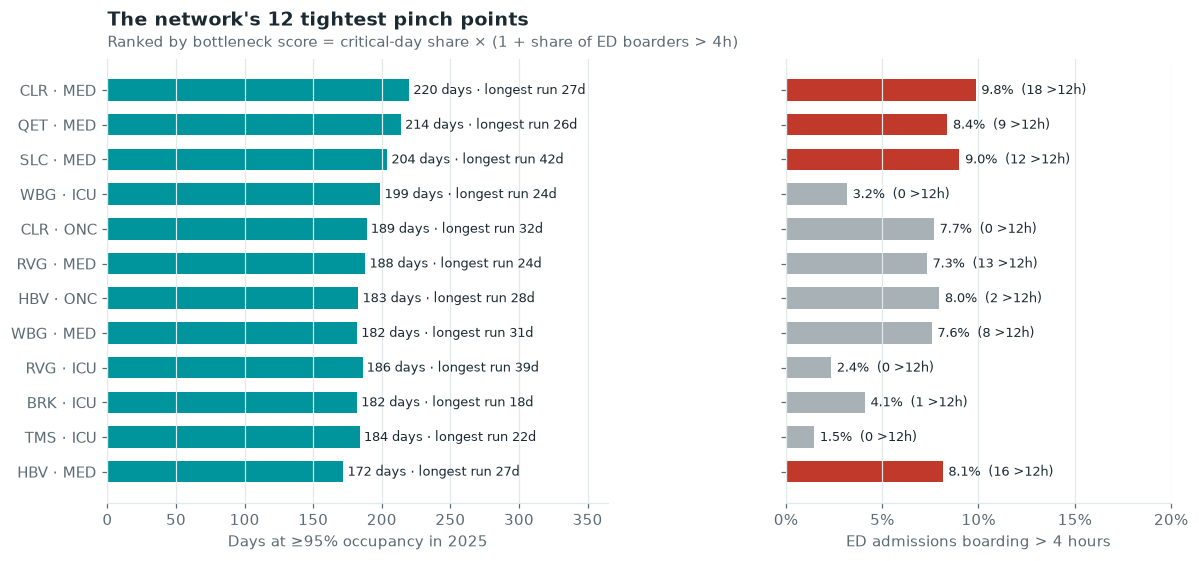

In [25]:
top = bott.head(12).iloc[::-1]
labels = top.hospital_code + " · " + top.department_code
fig, (ax0, ax1) = plt.subplots(1, 2, figsize=(11, 5.2), sharey=True, gridspec_kw={"width_ratios": [1.3, 1]})
ax0.barh(labels, top.critical_days, color=TEAL, height=0.62)
for yi, (d, run) in enumerate(zip(top.critical_days, top.longest_run_days)):
    ax0.text(d + 3, yi, f"{d} days · longest run {run}d", va="center", fontsize=8.3)
ax0.set_xlim(0, 365); ax0.set_xlabel("Days at ≥95% occupancy in 2025")
ax0.set_title("The network's 12 tightest pinch points")
subtitle(ax0, "Ranked by bottleneck score = critical-day share × (1 + share of ED boarders > 4h)")
ax1.barh(labels, top.share_boarding_over_4h, color=[RED if v >= 0.08 else CONTEXT for v in top.share_boarding_over_4h], height=0.62)
for yi, (v, n) in enumerate(zip(top.share_boarding_over_4h, top.trolley_waits_over_12h)):
    ax1.text(v + 0.003, yi, f"{v:.1%}  ({n} >12h)", va="center", fontsize=8.3)
ax1.xaxis.set_major_locator(mtick.MultipleLocator(0.05))
ax1.xaxis.set_major_formatter(mtick.PercentFormatter(1, decimals=0))
ax1.set_xlim(0, max(0.2, top.share_boarding_over_4h.max() * 1.5)); ax1.set_xlabel("ED admissions boarding > 4 hours")
for a in (ax0, ax1): a.grid(axis="y", visible=False)
fig.tight_layout()
save(fig, "09_capacity_bottlenecks")
plt.show()

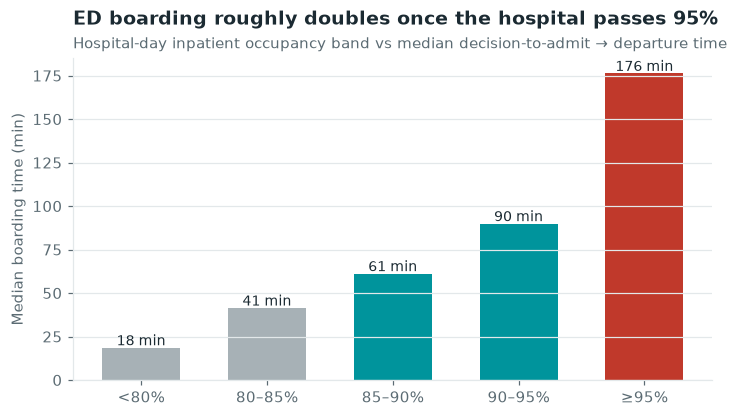

Correlation (hospital-day occupancy vs mean boarding): 0.58


In [26]:
# Does ward congestion back up into the ED? Hospital-level daily occupancy vs same-day boarding
board = pd.read_sql_query("""
    SELECT hospital_id, date(arrival_ts) AS day,
           AVG((strftime('%s', departure_ts) - strftime('%s', decision_to_admit_ts)) / 60.0) AS boarding_min
    FROM er_visits WHERE er_disposition = 'Admitted' AND arrival_ts >= '2025-01-01'
    GROUP BY 1, 2""", con)
hosp_day = occ.merge(pd.read_sql_query("SELECT hospital_id, hospital_code FROM hospitals", con)).groupby(
    ["hospital_id", "census_date"])[["occupied_beds", "staffed_beds"]].sum().reset_index()
hosp_day["occupancy"] = hosp_day.occupied_beds / hosp_day.staffed_beds
hosp_day["day"] = hosp_day.census_date.dt.strftime("%Y-%m-%d")
link = hosp_day.merge(board, on=["hospital_id", "day"])
link["band"] = pd.cut(link.occupancy, [0, 0.8, 0.85, 0.9, 0.95, 2], labels=["<80%", "80–85%", "85–90%", "90–95%", "≥95%"])
by_band = link.groupby("band", observed=True).boarding_min.median()

fig, ax = plt.subplots(figsize=(7.5, 3.8))
ax.bar(by_band.index.astype(str), by_band.values, color=[CONTEXT, CONTEXT, TEAL, TEAL, RED], width=0.62)
for x, v in enumerate(by_band.values):
    ax.text(x, v + 1.5, f"{v:.0f} min", ha="center", fontsize=9)
ax.set_ylabel("Median boarding time (min)"); ax.grid(axis="x", visible=False)
ax.set_title("ED boarding roughly doubles once the hospital passes 95%")
subtitle(ax, "Hospital-day inpatient occupancy band vs median decision-to-admit → departure time")
save(fig, "09b_boarding_vs_occupancy")
plt.show()
print(f"Correlation (hospital-day occupancy vs mean boarding): {link[['occupancy', 'boarding_min']].corr().iloc[0, 1]:.2f}")

## 10 · Staffing pressure and the operations scorecard (query 10)
Night-shift patients-per-nurse against safe-staffing ratios, then five KPIs ranked across hospitals (`RANK()`),
averaged, and split into tiers with `NTILE(3)`.

In [27]:
score = run_query("10_staffing_pressure_scorecard")
score

,overall_rank,tier,hospital_code,hospital_name,hospital_type,occupancy_rate,alos_days,ed_within_4h,readmission_rate_30d,night_patients_per_nurse,share_night_shifts_breaching_ratio,nurse_absence_rate,agency_share,mean_rank
0,1,Top third,EFG,Eastfield General Hospital,Regional General,0.8000,4.00,0.8655,0.0994,5.47,0.4887,0.0826,0.0465,2.4
1,2,Top third,TMS,Thameside General Hospital,Regional General,0.8069,4.07,0.8515,0.1085,5.53,0.4753,0.0893,0.0511,3.8
2,3,Top third,MRC,Moorcroft Community Hospital,Community,0.8057,4.20,0.8488,0.1112,4.19,0.2652,0.0830,0.0472,4.0
3,4,Top third,WBG,Westbrook General Hospital,Regional General,0.8372,4.14,0.8234,0.1026,6.63,0.6315,0.0834,0.0486,6.2
4,5,Top third,ASH,Ashby Vale Community Hospital,Community,0.8169,4.31,0.8377,0.1178,4.52,0.3430,0.0799,0.0455,6.6
5,6,Middle third,BRK,Bramble Rock Community Hospital,Community,0.8098,4.28,0.8310,0.1242,4.52,0.3693,0.0945,0.0516,6.8
6,7,Middle third,RVG,Riverside General Hospital,Regional General,0.8471,4.18,0.8160,0.1106,6.29,0.5805,0.0867,0.0460,7.8
7,8,Middle third,SLC,Saltmarsh Community Hospital,Community,0.8334,4.24,0.8136,0.1493,4.46,0.3266,0.0836,0.0497,8.0
8,9,Middle third,KMR,Kingsmead Regional Hospital,Regional General,0.8450,4.36,0.7989,0.1026,6.12,0.5469,0.1016,0.0614,8.4
9,10,Middle third,PNT,Pennant University Hospital,Teaching,0.8589,4.51,0.8203,0.0801,6.08,0.7051,0.1037,0.0572,9.6


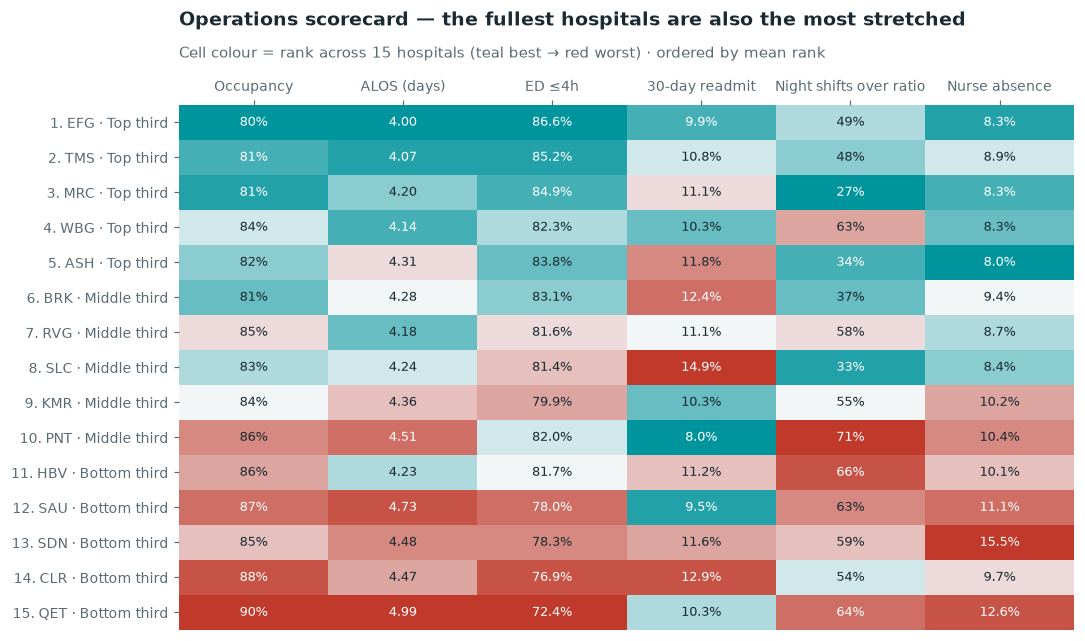

In [28]:
kpi_cols = {"occupancy_rate": ("Occupancy", True, "{:.0%}"), "alos_days": ("ALOS (days)", True, "{:.2f}"),
            "ed_within_4h": ("ED ≤4h", False, "{:.1%}"), "readmission_rate_30d": ("30-day readmit", True, "{:.1%}"),
            "share_night_shifts_breaching_ratio": ("Night shifts over ratio", True, "{:.0%}"),
            "nurse_absence_rate": ("Nurse absence", True, "{:.1%}")}
ranks = pd.DataFrame({k: score[k].rank(ascending=asc, method="min") for k, (_, asc, _) in kpi_cols.items()})
fig, ax = plt.subplots(figsize=(10.5, 6.2))
ax.imshow(ranks.values, cmap=LinearSegmentedColormap.from_list("rank", [TEAL, "#F4F7F8", RED]), aspect="auto", vmin=1, vmax=15)
for i in range(len(score)):
    for j, (k, (_, _, fmt)) in enumerate(kpi_cols.items()):
        ax.text(j, i, fmt.format(score[k].iat[i]), ha="center", va="center", fontsize=8.5,
                color="white" if ranks.iat[i, j] <= 3 or ranks.iat[i, j] >= 13 else INK)
ax.set_xticks(range(len(kpi_cols)), [v[0] for v in kpi_cols.values()], fontsize=9)
ax.xaxis.tick_top()
ax.set_yticks(range(len(score)), [f"{r}. {c} · {t}" for r, c, t in zip(score.overall_rank, score.hospital_code, score.tier)], fontsize=9)
ax.grid(False)
for s in ax.spines.values(): s.set_visible(False)
ax.set_title("Operations scorecard — the fullest hospitals are also the most stretched", pad=52)
ax.text(0, 1.09, "Cell colour = rank across 15 hospitals (teal best → red worst) · ordered by mean rank",
        transform=ax.transAxes, color=MUTED, fontsize=9.5)
save(fig, "10_scorecard")
plt.show()

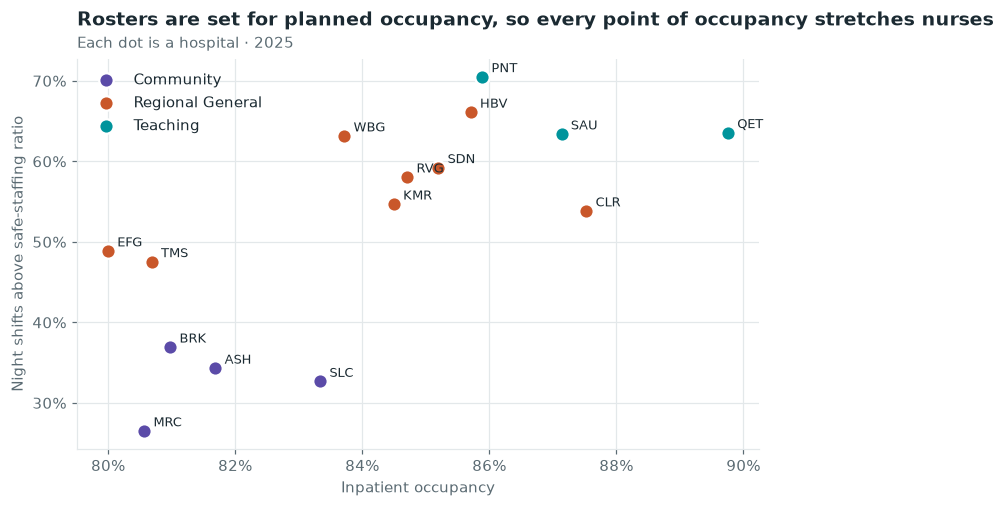

In [29]:
fig, ax = plt.subplots(figsize=(8, 4.6))
for t, g in score.groupby("hospital_type"):
    ax.scatter(g.occupancy_rate, g.share_night_shifts_breaching_ratio, s=90, color=TYPE_COLORS[t], label=t,
               edgecolor="white", linewidth=1.5, zorder=3)
for _, r in score.iterrows():
    ax.annotate(r.hospital_code, (r.occupancy_rate, r.share_night_shifts_breaching_ratio), xytext=(6, 3),
                textcoords="offset points", fontsize=8.5)
ax.xaxis.set_major_formatter(mtick.PercentFormatter(1, decimals=0))
ax.yaxis.set_major_formatter(mtick.PercentFormatter(1, decimals=0))
ax.set_xlabel("Inpatient occupancy"); ax.set_ylabel("Night shifts above safe-staffing ratio")
ax.legend(loc="upper left")
ax.set_title("Rosters are set for planned occupancy, so every point of occupancy stretches nurses")
subtitle(ax, "Each dot is a hospital · 2025")
save(fig, "10b_staffing_vs_occupancy")
plt.show()

## Key findings

1. **The network runs at ~85% occupancy on average, but General Medicine does not.** Medicine averages ~93%, five hospitals
   sit at or above 95% for the year, and a third of all ward-days are at or above the 95% "no slack" line.
2. **Capacity decisions show up in the data.** Medicine occupancy jumps to 100% in April after winter escalation beds close on
   31 March — demand had not fallen yet. ICU ran at 108% of staffed beds in the January flu surge.
3. **Long stays, not admissions, fill the beds.** Stays of 7+ days are ~16% of discharges but ~46% of bed-days. Two teaching
   hospitals (QET, SAU) carry ~9,200 excess bed-days against specialty benchmarks — roughly 25 beds.
4. **Discharges are a five-day service.** Weekends discharge ~37% fewer patients per day and Mondays catch up at ~1.5x the
   Tue–Fri rate, which keeps weekend occupancy high.
5. **ED waits are a whole-hospital problem.** Median boarding time rises from 18 minutes below 80% occupancy to ~3 hours at 95%+;
   waits keep climbing until 18:00, long after arrivals plateau. Harbourview's June redesign took its door-to-provider time
   from 4% above the network average to 23% below.
6. **Readmissions cluster in predictable groups.** Self-discharge (2.3x), heart failure (2.2x), COPD and hip fracture (~1.9x)
   carry the highest relative risk; 12% of readmissions land at a *different* hospital.
7. **Staffing tracks occupancy.** Rosters are set against planned occupancy, so the fullest hospitals breach safe-staffing
   ratios on the most night shifts. Southdown's second-half nursing attrition gives it the highest absence rate (15.5%).